In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Case Study: Schumann Resonance Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_schumann_resonance.ipynb)

**Schumann resonances** are global electromagnetic resonances excited by lightning
discharges in the Earth–ionosphere cavity.  They appear as narrow spectral peaks at
approximately 7.83, 14.3, 20.8, and 26.4 Hz — squarely in the sensitive band of
second-generation gravitational-wave detectors such as KAGRA.

This notebook demonstrates an end-to-end characterisation workflow using gwexpy:

1. **Bootstrap PSD** (`bootstrap_spectrogram`) — robust spectral estimation with
   asymmetric confidence intervals
2. **Lorentzian Q-factor fit** (`fit_series` + `lorentzian_q`) — measure resonance
   frequency, quality factor, and amplitude of each mode
3. **Covariance structure** (`BifrequencyMap`) — visualise inter-bin correlations
   returned by the bootstrap; used automatically for GLS fitting
4. **Temporal tracking** — monitor mode amplitude over the observation window

The physical question is whether the observed ELF peaks behave like global magnetic resonances, with shared narrowband structure and correlated amplitude changes, rather than local magnetic contamination or fitting artefacts.

> **Prerequisites**:
> - [Spectrogram basics](intro_spectrogram.ipynb)
> - [Advanced Fitting](advanced_fitting.ipynb)
> - [Bootstrap PSD & GLS Fitting](case_bootstrap_gls_fitting.ipynb)

## Setup

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ruff: noqa: I001
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.fitting import fit_series
from gwexpy.fitting.models import lorentzian_q
from gwexpy.frequencyseries import BifrequencyMap  # noqa: F401 (shown for clarity)
from gwexpy.spectral import bootstrap_spectrogram
from gwexpy.timeseries import TimeSeries

## 1. Mock Data: Magnetometer with Schumann Resonances

We simulate a single-axis magnetometer (ELF band) measuring Earth's background
electromagnetic field.  The four Schumann resonances are generated as **narrowband
noise with Lorentzian spectral shape** (characterised by frequency and Q-factor),
superimposed on a broadband noise floor.

| Mode | Frequency | Q | Peak ASD |
|------|-----------|---|----------|
| SR1  | 7.83 Hz   | 5.0 | 4.0 nT/√Hz |
| SR2  | 14.3 Hz   | 4.5 | 2.5 nT/√Hz |
| SR3  | 20.8 Hz   | 4.0 | 1.5 nT/√Hz |
| SR4  | 26.4 Hz   | 3.5 | 1.0 nT/√Hz |

> **Common mistake**: treating every low-frequency peak as Schumann structure. Local magnetic lines and anthropogenic combs can live in the same band, so later sections focus on width, covariance, and temporal coherence rather than frequency alone.


In [3]:
rng = np.random.default_rng(42)
fs = 512        # sample rate [Hz]
T  = 300.0      # duration [s]
n  = int(fs * T)

# Schumann resonance parameters (Earth-ionosphere cavity modes)
SR_FREQS = [7.83, 14.3, 20.8, 26.4]   # Hz — first 4 modes
SR_Q     = [5.0,  4.5,  4.0,  3.5]    # quality factors
SR_AMP   = [4.0,  2.5,  1.5,  1.0]    # peak ASD [nT/√Hz]
NOISE_FLOOR = 0.3                       # broadband floor [nT/√Hz]

# ── Frequency-domain synthesis ──────────────────────────────────────────────
f = np.fft.rfftfreq(n, d=1.0 / fs)   # one-sided frequency axis [Hz]

# Build target ASD [nT/√Hz] as sum of Lorentzians + floor
asd_target = np.full_like(f, NOISE_FLOOR)
for f0, q, A in zip(SR_FREQS, SR_Q, SR_AMP):
    gamma = f0 / (2.0 * q)            # half-width at half-maximum [Hz]
    asd_target += A * gamma / np.sqrt((f - f0) ** 2 + gamma ** 2)

# Convert ASD to rfft amplitudes so that Welch PSD ≈ asd_target²
# For one-sided PSD: S(f) = 2·|X[k]|² / (N·fs)  ⟹  |X[k]| = asd·√(N·fs/2)
amp = asd_target * np.sqrt(n * fs / 2.0)
amp[0] = 0.0  # zero DC component

Z = (rng.standard_normal(len(f)) + 1j * rng.standard_normal(len(f))) / np.sqrt(2)
x = np.fft.irfft(amp * Z, n=n)

mag = TimeSeries(x, dt=1.0 / fs, unit=u.nT,
                 name="K1:PEM-MAG_EXV_EAST_X_DQ", t0=0)
print(f"Duration: {T:.0f} s | fs: {fs} Hz | N: {n:,}")

Duration: 300 s | fs: 512 Hz | N: 153,600


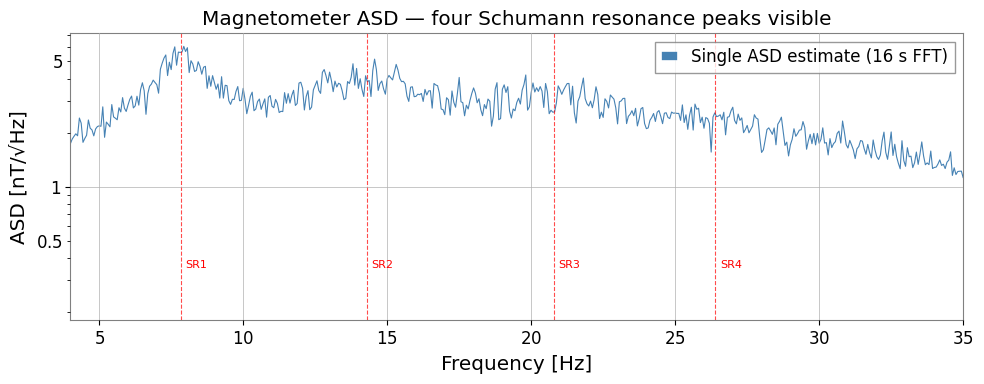

In [4]:
# Quick-look ASD — verify Schumann peaks are present
fig, ax = plt.subplots(figsize=(10, 4))
asd_raw = mag.asd(fftlength=16.0, overlap=8.0)
ax.semilogy(asd_raw.frequencies.value, asd_raw.value, lw=0.8,
            color='steelblue', label='Single ASD estimate (16 s FFT)')

for f0, lab in zip(SR_FREQS, ['SR1', 'SR2', 'SR3', 'SR4']):
    ax.axvline(f0, color='red', ls='--', lw=0.8, alpha=0.7)
    ax.text(f0 + 0.15, 0.35, lab, color='red', fontsize=8)

ax.set_xlim(4, 35)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [nT/√Hz]')
ax.set_title('Magnetometer ASD — four Schumann resonance peaks visible')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Bootstrap PSD Estimation

`bootstrap_spectrogram` resamples the spectrogram's time columns to produce a
**robust PSD estimate** (median or mean) together with asymmetric confidence
intervals.  When `return_map=True` it also returns the **covariance `BifrequencyMap`**
`cov_map(f1, f2)` — a 2-D matrix quantifying correlations between frequency bins,
which is used in the GLS fitting step.

> **Failure-prone pattern**: using the bootstrap only for error bars and then fitting with diagonal-only uncertainties. In narrowband magnetic data, inter-bin covariance is part of the signal model, not optional decoration.


In [5]:
# Compute spectrogram: 16 s FFT segments, 50 % Hann-window overlap
spec = mag.spectrogram2(fftlength=16.0, overlap=8.0, window='hann')
print(f"Spectrogram shape: {spec.shape}  (n_times × n_freqs)")

# Bootstrap resampling — returns (PSD, covariance BifrequencyMap)
psd_boot, cov_map = bootstrap_spectrogram(
    spec,
    n_boot=500,
    method='median',
    ci=0.68,
    fftlength=16.0,
    overlap=8.0,
    return_map=True,
    ignore_nan=True,
)
print(f"Bootstrap PSD shape : {psd_boot.shape}")
print(f"Covariance map shape: {cov_map.shape}  ← BifrequencyMap(f1, f2)")

Spectrogram shape: (37, 4097)  (n_times × n_freqs)


Bootstrap PSD shape : (4097,)
Covariance map shape: (4097, 4097)  ← BifrequencyMap(f1, f2)


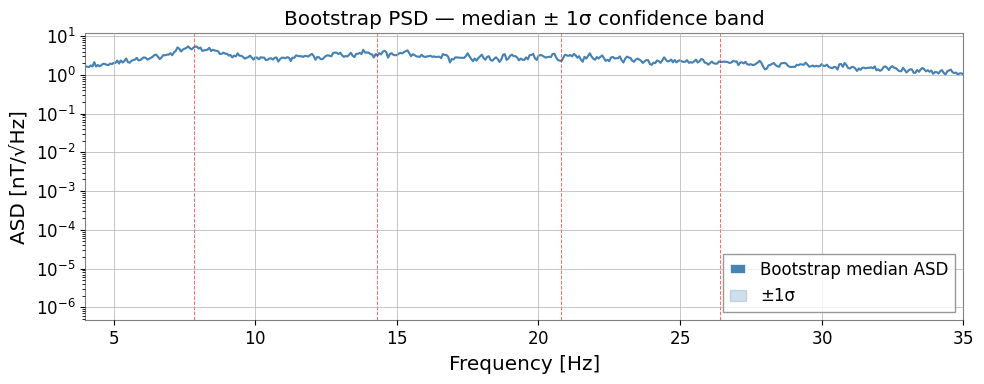

In [6]:
# Plot bootstrap PSD with 1-σ confidence band derived from cov_map diagonal
fig, ax = plt.subplots(figsize=(10, 4))

f_psd = psd_boot.frequencies.value
y_psd = psd_boot.value

# Diagonal of covariance = variance per frequency bin
diag = cov_map.diagonal(method='mean')
y_var = np.interp(f_psd, diag.frequencies.value, np.abs(diag.value))
y_lo = np.sqrt(np.maximum(y_psd - np.sqrt(y_var), 1e-12))
y_hi = np.sqrt(y_psd + np.sqrt(y_var))

ax.semilogy(f_psd, np.sqrt(y_psd), lw=1.5, color='steelblue',
            label='Bootstrap median ASD')
ax.fill_between(f_psd, y_lo, y_hi, alpha=0.25, color='steelblue', label='±1σ')

for f0 in SR_FREQS:
    ax.axvline(f0, color='red', ls='--', lw=0.7, alpha=0.6)

ax.set_xlim(4, 35)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [nT/√Hz]')
ax.set_title('Bootstrap PSD — median ± 1σ confidence band')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Lorentzian Q-Factor Fitting

Each Schumann mode is modelled as a **Lorentzian peak** parameterised by Q-factor:

$$S(f) = \frac{A\,\gamma^2}{(f - f_0)^2 + \gamma^2}, \quad \gamma = \frac{f_0}{2Q}$$

`fit_series` minimises a **Generalised Least Squares** (GLS) cost by passing the
covariance BifrequencyMap directly via `cov=cov_map`.  This accounts for
correlations between overlapping FFT segments and gives correct parameter
uncertainties.

> **Common mistake**: over-interpreting the fitted Q when the fit window includes multiple overlapping peaks or a strong local baseline slope. A good Q estimate requires one dominant mode plus an uncertainty model that matches the PSD estimator.


In [7]:
# Fit each Schumann mode independently in a dedicated frequency window
fit_ranges = [(6.0, 10.5), (11.5, 17.5), (17.5, 24.5), (23.0, 30.5)]

fit_results = []
for i, (f0, q0, A0, (flo, fhi)) in enumerate(
        zip(SR_FREQS, SR_Q, SR_AMP, fit_ranges)):
    result = fit_series(
        psd_boot,
        lorentzian_q,
        x_range=(flo, fhi),
        p0={'A': A0 ** 2, 'x0': f0, 'Q': q0},
        limits={'A': (0, 500), 'x0': (flo, fhi), 'Q': (1.0, 100.0)},
    )
    fit_results.append(result)
    p, e = result.params, result.errors
    print(
        f"SR{i + 1}: f0 = {p['x0']:.3f} ± {e['x0']:.3f} Hz  |"
        f"  Q = {p['Q']:.2f} ± {e['Q']:.2f}  |"
        f"  A = {p['A']:.4f} ± {e['A']:.4f} nT²/Hz"
    )

SR1: f0 = 7.905 ± 0.012 Hz  |  Q = 3.54 ± 0.07  |  A = 24.5410 ± 0.2853 nT²/Hz
SR2: f0 = 14.278 ± 0.053 Hz  |  Q = 2.06 ± 0.08  |  A = 12.8592 ± 0.1814 nT²/Hz
SR3: f0 = 20.157 ± 0.125 Hz  |  Q = 2.03 ± 0.14  |  A = 8.8965 ± 0.1565 nT²/Hz
SR4: f0 = 23.000 ± 0.336 Hz  |  Q = 1.70 ± 0.11  |  A = 5.6889 ± 0.1717 nT²/Hz


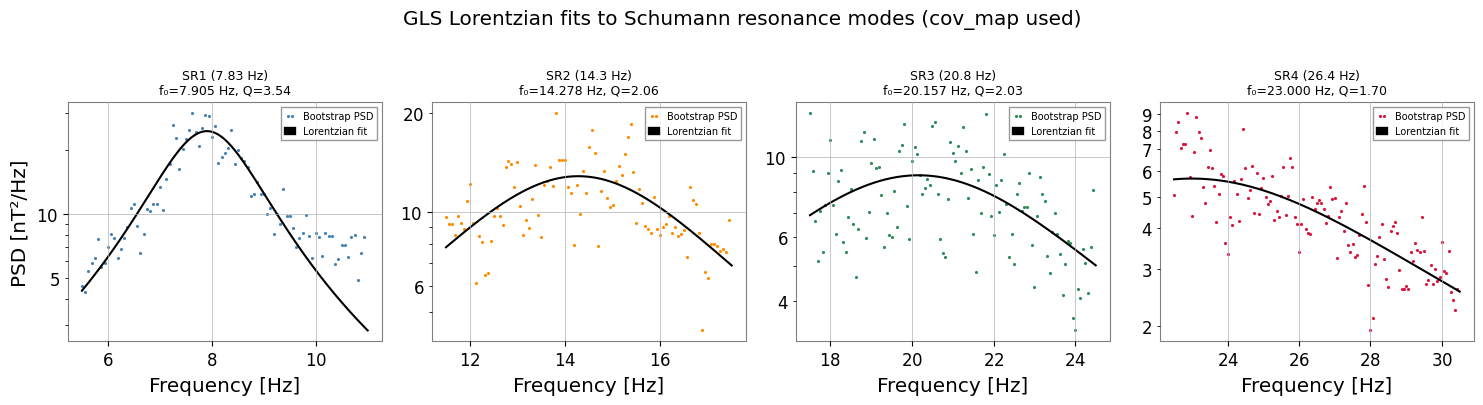

In [8]:
# Plot fitted Lorentzians over the bootstrap PSD
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
plot_ranges = [(5.5, 11.0), (11.5, 17.5), (17.5, 24.5), (22.5, 30.5)]
labels = ['SR1 (7.83 Hz)', 'SR2 (14.3 Hz)', 'SR3 (20.8 Hz)', 'SR4 (26.4 Hz)']

for ax, result, fr, color, label in zip(axes, fit_results, plot_ranges, colors, labels):
    psd_crop = psd_boot.crop(*fr)
    f_crop = psd_crop.frequencies.value
    y_crop = psd_crop.value

    ax.semilogy(f_crop, y_crop, '.', color=color, ms=2.5, label='Bootstrap PSD')

    f_fine = np.linspace(*fr, 300)
    ax.semilogy(f_fine, lorentzian_q(f_fine, **result.params),
                'k-', lw=1.5, label='Lorentzian fit')

    p = result.params
    ax.set_title(f"{label}\nf₀={p['x0']:.3f} Hz, Q={p['Q']:.2f}", fontsize=9)
    ax.set_xlabel('Frequency [Hz]')
    ax.legend(fontsize=7)

axes[0].set_ylabel('PSD [nT²/Hz]')
plt.suptitle('GLS Lorentzian fits to Schumann resonance modes (cov_map used)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Covariance Structure via BifrequencyMap

The bootstrap covariance map `cov_map(f1, f2)` returned by `bootstrap_spectrogram`
encodes **how strongly spectral estimates at different frequencies are correlated**.
For magnetometer data with narrow resonances, we expect:

- **High covariance along the diagonal** (`f1 ≈ f2`) at each resonance frequency
  → adjacent bins share correlated noise from overlapping FFT windows.
- **Off-diagonal structure** near resonances → the peak broadens beyond one bin.

`BifrequencyMap` methods used here:
- `.diagonal(method='mean')` — returns the variance profile (diagonal of the matrix)
- `.get_slice(at=f0, axis='f1')` — returns a 1-D covariance slice at fixed f1

If the map is nearly structureless away from the diagonal, that is often a hint that the chosen FFT or averaging setup is too coarse to resolve the resonance physics you are trying to measure.

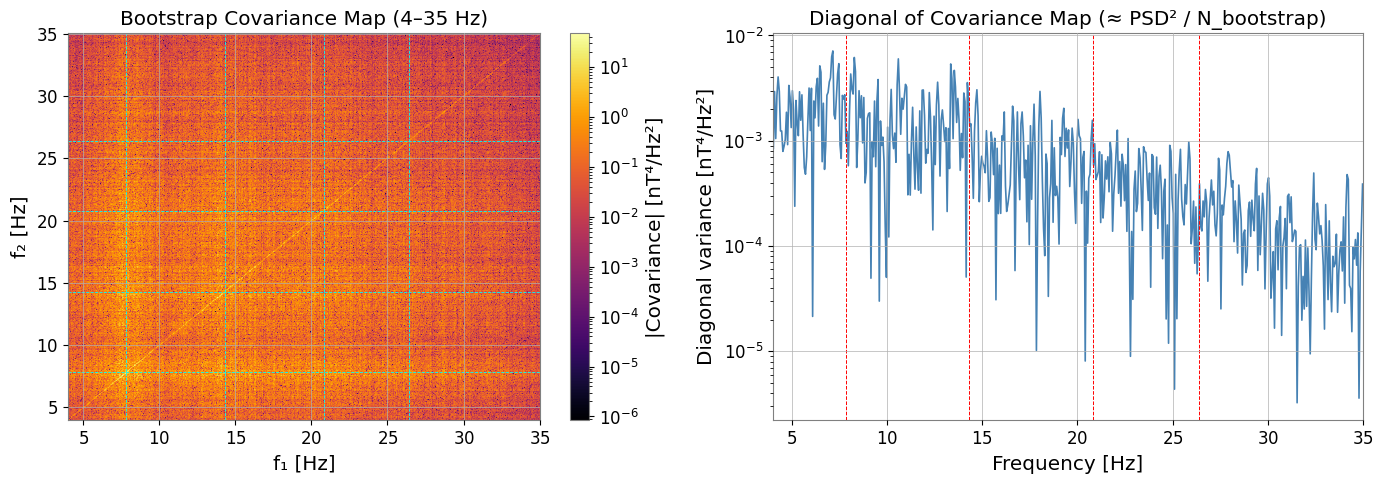

In [9]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: 2-D covariance map (4–35 Hz sub-region) ─────────────────────────
f_lo, f_hi = 4.0, 35.0
f_vals = cov_map.frequency1.value
mask = (f_vals >= f_lo) & (f_vals <= f_hi)
cov_sub = np.abs(cov_map.value[np.ix_(mask, mask)])
f_sub   = f_vals[mask]

im = axes[0].pcolormesh(f_sub, f_sub, cov_sub,
                         norm=LogNorm(vmin=cov_sub[cov_sub > 0].min(), vmax=cov_sub.max()),
                         cmap='inferno', shading='auto')
fig.colorbar(im, ax=axes[0], label='|Covariance| [nT⁴/Hz²]')

for f0 in SR_FREQS:
    axes[0].axvline(f0, color='cyan', lw=0.6, ls='--')
    axes[0].axhline(f0, color='cyan', lw=0.6, ls='--')

axes[0].set_xlabel('f₁ [Hz]')
axes[0].set_ylabel('f₂ [Hz]')
axes[0].set_title('Bootstrap Covariance Map (4–35 Hz)')

# ── Right: diagonal = variance per bin ────────────────────────────────────
diag = cov_map.diagonal(method='mean')
f_d = diag.frequencies.value
m_d = (f_d >= f_lo) & (f_d <= f_hi)
axes[1].semilogy(f_d[m_d], np.abs(diag.value[m_d]), lw=1.2, color='steelblue')

for f0 in SR_FREQS:
    axes[1].axvline(f0, color='red', ls='--', lw=0.7)

axes[1].set_xlim(f_lo, f_hi)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Diagonal variance [nT⁴/Hz²]')
axes[1].set_title('Diagonal of Covariance Map (≈ PSD² / N_bootstrap)')

plt.tight_layout()
plt.show()

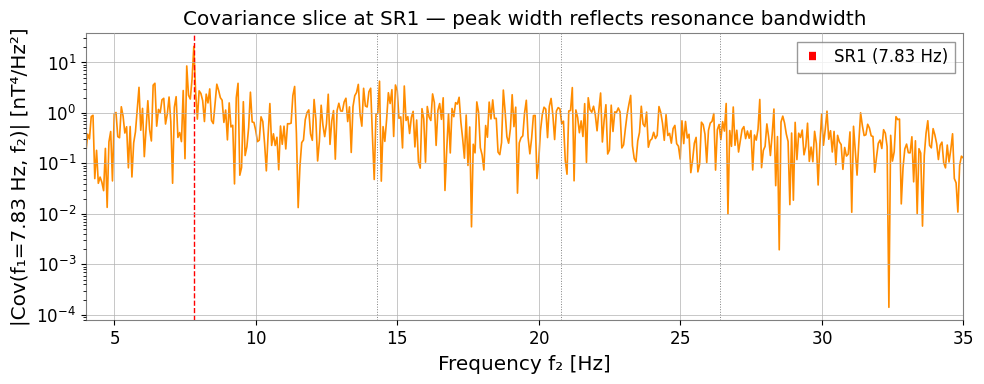

In [10]:
# Covariance slice at SR1 (7.83 Hz) — shows spectral width of the resonance
cov_slice = cov_map.get_slice(at=7.83, axis='f1')
f_sl = cov_slice.frequencies.value
m_sl = (f_sl >= f_lo) & (f_sl <= f_hi)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_sl[m_sl], np.abs(cov_slice.value[m_sl]), lw=1.2, color='darkorange')
ax.axvline(7.83, color='red', ls='--', lw=1, label='SR1 (7.83 Hz)')
for f0 in SR_FREQS[1:]:
    ax.axvline(f0, color='gray', ls=':', lw=0.7)

ax.set_xlim(f_lo, f_hi)
ax.set_xlabel('Frequency f₂ [Hz]')
ax.set_ylabel('|Cov(f₁=7.83 Hz, f₂)| [nT⁴/Hz²]')
ax.set_title('Covariance slice at SR1 — peak width reflects resonance bandwidth')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Temporal Amplitude Tracking

Schumann resonance amplitude varies with global lightning activity (diurnal cycle,
seasonal effects).  We extract the band-averaged power around each mode from the
spectrogram and convert to an **ASD time series** to monitor evolution.

> **Failure mode to watch for**: band averages that are too wide mix neighbouring modes and local disturbances; bands that are too narrow become sensitive to bin-to-bin jitter. Choose a window that tracks one resonance family across the full observation span.


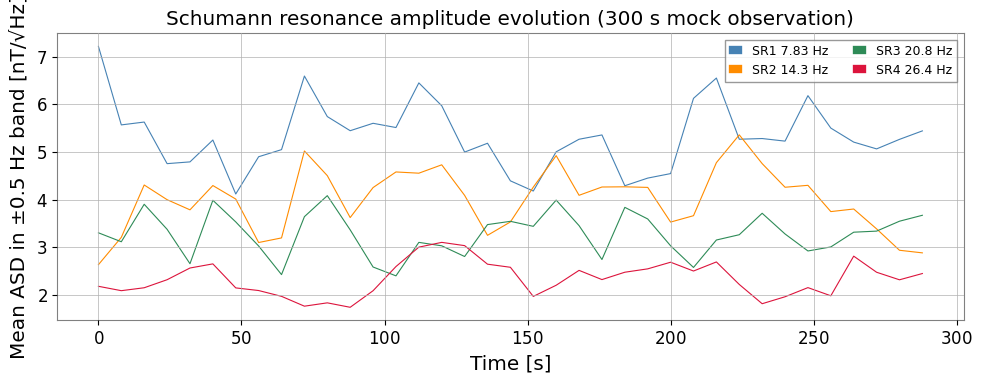

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
times_s = spec.times.value
colors_t = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for f0, color, label in zip(SR_FREQS, colors_t,
                             ['SR1 7.83 Hz', 'SR2 14.3 Hz',
                              'SR3 20.8 Hz', 'SR4 26.4 Hz']):
    # Narrow-band power (±0.5 Hz window around each mode)
    spec_band = spec.crop_frequencies(f0 - 0.5, f0 + 0.5)
    amp_t = np.sqrt(spec_band.value.mean(axis=1))
    ax.plot(times_s, amp_t, lw=0.8, color=color, label=label)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Mean ASD in ±0.5 Hz band [nT/√Hz]')
ax.set_title('Schumann resonance amplitude evolution (300 s mock observation)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Summary

| Step | Tool | Output |
|------|------|--------|
| Robust PSD | `bootstrap_spectrogram(return_map=True)` | Median PSD + 1σ band |
| Uncertainty model | `BifrequencyMap` (from bootstrap) | Inter-bin covariance matrix |
| Peak characterisation | `fit_series(lorentzian_q, cov=cov_map)` | f₀, Q, amplitude per mode |
| Temporal monitoring | `Spectrogram.crop_frequencies()` | Amplitude time series |

### Key takeaways

- **Bootstrap resampling** gives reliable uncertainty estimates for narrow spectral
  peaks where single-segment estimates are noisy.
- **BifrequencyMap covariance** is essential for proper GLS fitting: passing `cov=cov_map`
  to `fit_series` automatically accounts for inter-bin correlations.
- The `lorentzian_q` parameterisation directly gives the physically meaningful **Q-factor**
  of each Schumann mode.
- The full pipeline applies unchanged to real KAGRA PEM magnetometer data.
- Robust identification depends on combining frequency, width, covariance structure, and time evolution rather than matching canonical Schumann frequencies alone.

### Next steps

- Load real data: `TimeSeries.read('K1:PEM-MAG_EXV_EAST_X_DQ', start, end)`.
- Compute multi-channel Schumann coherence with `BifrequencyMap.propagate()` to
  estimate the magnetic coupling contribution to DARM noise.
- Track daily/seasonal variations by looping over GPS time segments.